In [5]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:

#Load data
data_matrix = pd.read_csv('./data_matrix.csv', index_col=0)
classes = pd.read_csv('./classes.csv', index_col=0)['class']

# ---------------
# Task 1: Standardize the data matrix
# ---------------
mean = data_matrix.mean(axis=0)
sttd = data_matrix.std(axis=0)
data_matrix_standardized = (data_matrix - mean) / sttd   # FIXED


In [7]:

# ---------------
# Task 2: Perform PCA
# ---------------
pca = PCA()
principal_components = pca.fit_transform(data_matrix_standardized)

print(f'Number of features in the data matrix: {data_matrix.shape[1]}')
print(f'Number of features in the principal components: {principal_components.shape[1]}')


Number of features in the data matrix: 10
Number of features in the principal components: 10


In [8]:

# ---------------
# Task 3: Eigenvalues and Eigenvectors
# ---------------
singular_values = pca.singular_values_
n_samples = data_matrix_standardized.shape[0]
eigenvalues = (singular_values ** 2) / (n_samples - 1)   # FIXED
eigenvectors = pca.components_.T   # FIXED

print("Eigenvalues:", eigenvalues)
print("Eigenvectors shape:", eigenvectors.shape)


Eigenvalues: [4.2239909  1.5751879  1.01180532 0.9940127  0.74201939 0.65008647
 0.4075386  0.22036243 0.15475338 0.02024291]
Eigenvectors shape: (10, 10)


In [9]:

# ---------------
# Task 4: Variance ratios
# ---------------
principal_axes_variance_ratios = pca.explained_variance_ratio_
principal_axes_variance_percents = principal_axes_variance_ratios * 100   # FIXED
print("Variance ratios (%):", principal_axes_variance_percents)


Variance ratios (%): [42.23990899 15.75187902 10.1180532   9.94012697  7.42019394  6.50086467
  4.07538598  2.20362427  1.54753381  0.20242914]


In [10]:

# ---------------
# Task 5: PCA with 2 components
# ---------------
pca2 = PCA(n_components=2)
principal_components = pca2.fit_transform(data_matrix_standardized)

print(f'Number of Principal Component Features: {principal_components.shape[1]}')
print(f'Number of Original Data Features: {data_matrix_standardized.shape[1]}')


Number of Principal Component Features: 2
Number of Original Data Features: 10


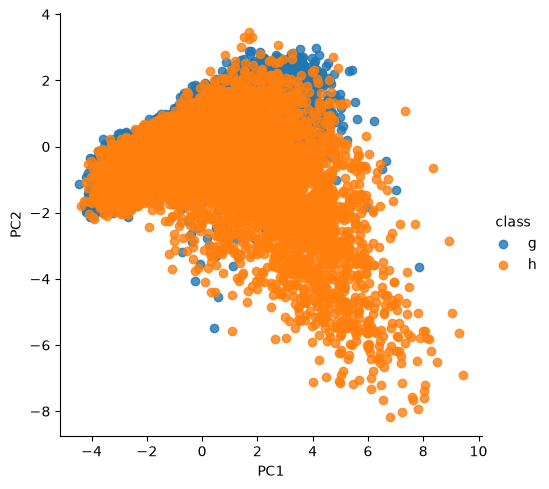

In [11]:

# ---------------
# Task 6: Scatter plot with class hue
# ---------------
principal_components_data = pd.DataFrame({
    'PC1': principal_components[:, 0],
    'PC2': principal_components[:, 1],
    'class': classes,
})

sns.lmplot(x='PC1', y='PC2', data=principal_components_data, hue='class', fit_reg=False)  # FIXED
plt.show()


In [12]:

# Encode classes
y = classes.astype('category').cat.codes

# ---------------
# Task 7: SVC with PCA features
# ---------------
pca_1 = PCA(n_components=2)
X = pca_1.fit_transform(data_matrix_standardized)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

svc_1 = LinearSVC(random_state=0, tol=1e-5)
svc_1.fit(X_train, y_train)
score_1 = svc_1.score(X_test, y_test)   # FIXED
print(f'Score for model with 2 PCA features: {score_1}')


Score for model with 2 PCA features: 0.7417556157400031


In [13]:

# ---------------
# Task 8: SVC with original first two features
# ---------------
first_two_original_features = [0, 1]
X_original = data_matrix_standardized.iloc[:, first_two_original_features]

X_train, X_test, y_train, y_test = train_test_split(X_original, y, test_size=0.33, random_state=42)

svc_2 = LinearSVC(random_state=0)
svc_2.fit(X_train, y_train)
score_2 = svc_2.score(X_test, y_test)   # FIXED
print(f'Score for model with 2 original features: {score_2}')


Score for model with 2 original features: 0.7192926557272582
